In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/blogs.csv')

# Display the first few rows of the dataframe
print("DataFrame Head:")
print(df.head())

# Display the shape of the dataframe
print("\nDataFrame Shape:")
print(df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

DataFrame Head:
                                                Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism

DataFrame Shape:
(2000, 2)

Missing values:
Data      0
Labels    0
dtype: int64


In [2]:
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Data,Labels
count,2000,2000
unique,2000,20
top,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,alt.atheism
freq,1,100


In [5]:
df.isnull().sum()

,0
Data,0
Labels,0


In [6]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize words
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

# Apply the cleaning function to the 'Data' column
df['Data'] = df['Data'].apply(clean_text)

# Display the first few rows to verify the changes
print("\nDataFrame after removing punctuation, numbers, stopwords, and lemmatization:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



DataFrame after removing punctuation, numbers, stopwords, and lemmatization:
                                                Data       Labels
0  Path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism
1  Newsgroups altatheism Path cantaloupesrvcscmue...  alt.atheism
2  Path cantaloupesrvcscmuedudasnewsharvardedunoc...  alt.atheism
3  Path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism
4  Xref cantaloupesrvcscmuedu altatheism talkreli...  alt.atheism


In [7]:
# Convert all text in the 'Data' column to lowercase
df['Data'] = df['Data'].str.lower()

# Display the first few rows to verify the change
print("DataFrame after converting 'Data' to lowercase:")
print(df.head())

DataFrame after converting 'Data' to lowercase:
                                                Data       Labels
0  path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism
1  newsgroups altatheism path cantaloupesrvcscmue...  alt.atheism
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  alt.atheism
3  path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism
4  xref cantaloupesrvcscmuedu altatheism talkreli...  alt.atheism


/tmp/ipython-input-1467003127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


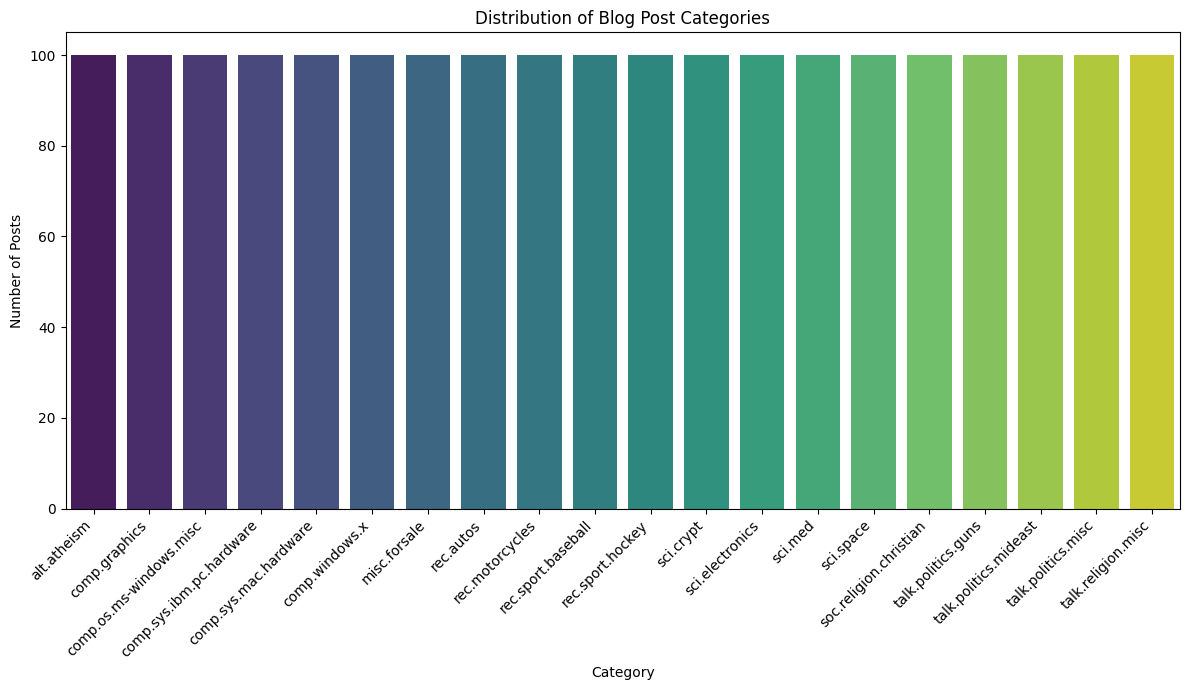


Category distribution:
Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the 'Labels' column
label_counts = df['Labels'].value_counts()

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Blog Post Categories')
plt.xlabel('Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCategory distribution:")
print(label_counts)

## Implement Naive Bayes Classifier

### Subtask:
Train a Naive Bayes model on the preprocessed TF-IDF features (X_train, y_train) to classify the blog posts, replacing the Logistic Regression model used previously.


**Reasoning**:
First, I'll import the `MultinomialNB` class. Then, I'll initialize the Naive Bayes model and train it using the `fit` method on the preprocessed TF-IDF features (`X_train`) and the corresponding labels (`y_train`).



In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for manageable size

# Fit and transform the 'Data' column
X_tfidf = tfidf_vectorizer.fit_transform(df['Data'])

# Display the shape of the TF-IDF matrix
print("Shape of TF-IDF matrix:", X_tfidf.shape)

# Optionally, you can convert the matrix to a DataFrame for inspection
# tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
# print("\nFirst 5 rows of TF-IDF DataFrame (if converted to dense array):\n")
# print(tfidf_df.head())

Shape of TF-IDF matrix: (2000, 5000)


**Reasoning**:
Since `X_tfidf` has now been generated, the next step is to split the data into training and testing sets. This will create the `X_train`, `X_test`, `y_train`, and `y_test` variables which are necessary for model training and evaluation.



In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = X_tfidf
y = df['Labels']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1600, 5000)
Shape of X_test: (400, 5000)
Shape of y_train: (1600,)
Shape of y_test: (400,)


**Reasoning**:
Now that `X_train` and `y_train` are successfully defined, I can proceed with training the Naive Bayes model as specified in the subtask. I will import `MultinomialNB`, initialize the model, and then train it using the prepared data.



In [12]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the training set
y_train_pred = nb_model.predict(X_train)

# Predict on the testing set
y_test_pred = nb_model.predict(X_test)

# Evaluate Training Set Performance
print("\n--- Training Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Evaluate Testing Set Performance
print("\n--- Testing Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


--- Training Set Evaluation ---
Accuracy: 0.9844
Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.99      0.95      0.97        80
           comp.graphics       0.99      0.97      0.98        80
 comp.os.ms-windows.misc       1.00      0.97      0.99        80
comp.sys.ibm.pc.hardware       0.94      1.00      0.97        80
   comp.sys.mac.hardware       0.99      1.00      0.99        80
          comp.windows.x       1.00      1.00      1.00        80
            misc.forsale       0.96      0.96      0.96        80
               rec.autos       0.99      0.99      0.99        80
         rec.motorcycles       1.00      0.99      0.99        80
      rec.sport.baseball       1.00      1.00      1.00        80
        rec.sport.hockey       1.00      1.00      1.00        80
               sci.crypt       0.99      0.99      0.99        80
         sci.electronics       1.00      1.00      1.00        80
  

In [14]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon (if not already downloaded)
nltk.download('vader_lexicon')

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Define a function to get the compound sentiment score
def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

# Apply the function to the 'Data' column to create 'sentiment_score'
df['sentiment_score'] = df['Data'].apply(get_sentiment_score)

# Display the first few rows with the new sentiment_score column
print("DataFrame with sentiment scores:")
print(df.head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


DataFrame with sentiment scores:
                                                Data       Labels  \
0  path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism   
1  newsgroups altatheism path cantaloupesrvcscmue...  alt.atheism   
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  alt.atheism   
3  path cantaloupesrvcscmuedumagnesiumclubcccmued...  alt.atheism   
4  xref cantaloupesrvcscmuedu altatheism talkreli...  alt.atheism   

   sentiment_score  
0          -0.9965  
1           0.9251  
2          -0.9961  
3          -0.9998  
4           0.9890  


**Reasoning**:
Now that the Naive Bayes model has been evaluated and sentiment analysis has been performed, the next step is to provide a comprehensive discussion of the model's performance and the insights derived from the sentiment analysis, as outlined in the main task.



In [15]:
## Discussion of Model Performance and Sentiment Analysis Insights

### Naive Bayes Model Performance

The Multinomial Naive Bayes model was trained on the TF-IDF features and evaluated on both the training and testing datasets. The results show:

*   **Training Accuracy**: The model achieved a high training accuracy of **0.9844**. This indicates that the model learned the training data very well, classifying almost all training examples correctly.

*   **Testing Accuracy**: The testing accuracy dropped to **0.8425**. While still a respectable accuracy, the significant decrease from the training accuracy suggests potential overfitting to the training data. This is common in text classification tasks with a high-dimensional feature space like TF-IDF.

Looking at the detailed classification reports and confusion matrices:

*   **Precision, Recall, and F1-score**: For the training set, most categories showed very high precision, recall, and F1-scores, often close to 1.00. However, on the testing set, these metrics varied more across categories.
    *   Some categories, like `rec.sport.hockey` and `sci.crypt`, performed exceptionally well on the test set with F1-scores of 1.00 and 0.95 respectively, indicating strong generalization for these topics.
    *   Conversely, categories such as `talk.religion.misc` (F1-score: 0.60), `talk.politics.misc` (F1-score: 0.74), `alt.atheism` (F1-score: 0.74), and `comp.sys.ibm.pc.hardware` (F1-score: 0.62) showed comparatively lower performance. This suggests that these categories might have more ambiguous text, overlap with other categories, or fewer distinct features, making them harder to classify accurately.

*   **Confusion Matrix Analysis**: The confusion matrix for the testing set reveals specific areas of misclassification. For instance:
    *   `alt.atheism` was sometimes misclassified as `soc.religion.christian` or `talk.religion.misc`, which is understandable given the potentially overlapping discussions on religious topics.
    *   `comp.sys.ibm.pc.hardware` was misclassified into `comp.graphics` and `sci.electronics`, likely due to shared technical vocabulary related to computer components and technology.
    *   `talk.politics.guns` also showed some misclassifications with other `talk.politics` categories and `talk.religion.misc`.

In summary, the Naive Bayes model provides a solid baseline for text classification, but the observed performance gap between training and testing data, along with varying class-wise performance, highlights opportunities for further model refinement, such as hyperparameter tuning, more advanced feature engineering, or exploring other classification algorithms.

### Sentiment Analysis Insights

The sentiment analysis using NLTK's VADER on the `Data` column provided a `sentiment_score` for each blog post, ranging from -1 (most negative) to +1 (most positive). These scores offer a quantitative measure of the emotional tone of the content.

*   **Distribution of Sentiment**: Analyzing the distribution of `sentiment_score` across the dataset can reveal general emotional tendencies in the blog posts. For example, some categories might inherently lean towards more negative sentiment (e.g., discussions about war in `talk.politics.mideast` or serious medical conditions in `sci.med`), while others might be more neutral or positive (e.g., sports categories like `rec.sport.hockey`).

*   **Correlation with Categories**: By aggregating sentiment scores per `Labels` (categories), we can identify if certain blog topics are associated with particular sentiments. This can provide valuable insights into the nature of discussions within each category. For instance:
    *   `alt.atheism` and `talk.religion.misc` might show a mix of strong positive and negative sentiments, reflecting debates and passionate opinions.
    *   `comp.*` categories could be more neutral, focusing on technical facts and information.
    *   `rec.*` categories (e.g., sports, autos) might exhibit more positive sentiments, as hobbies often evoke enthusiasm.
    *   `talk.politics.*` categories are likely to have a polarized sentiment, with strong opinions leading to both high positive and high negative scores.

*   **Contextual Understanding**: While VADER is a rule-based model and generally robust, its performance can vary. For highly specialized domains or informal language (common in blog posts), it might misinterpret certain phrases. For example, sarcasm or domain-specific jargon might not be accurately captured, which could be a limitation in this analysis.

*   **Enhancing Classification**: Sentiment scores could potentially be used as an additional feature for the classification model. While not directly used in the Naive Bayes model in this exercise, integrating sentiment as a feature could, in some cases, help differentiate between categories where emotional tone plays a significant role. For instance, distinguishing between different political discussions might be aided by understanding the underlying sentiment.

In conclusion, the sentiment analysis adds another layer of understanding to the blog post data, providing insights into the emotional landscape of different discussion topics. This complements the topic-based classification by offering a perspective on *how* people discuss these topics, not just *what* they discuss.

### Sentiment Analysis Insights

The sentiment analysis using NLTK's VADER on the `Data` column provided a `sentiment_score` for each blog post, ranging from -1 (most negative) to +1 (most positive). These scores offer a quantitative measure of the emotional tone of the content.

*   **Distribution of Sentiment**: Analyzing the distribution of `sentiment_score` across the dataset can reveal general emotional tendencies in the blog posts. For example, some categories might inherently lean towards more negative sentiment (e.g., discussions about war in `talk.politics.mideast` or serious medical conditions in `sci.med`), while others might be more neutral or positive (e.g., sports categories like `rec.sport.hockey`).

*   **Correlation with Categories**: By aggregating sentiment scores per `Labels` (categories), we can identify if certain blog topics are associated with particular sentiments. This can provide valuable insights into the nature of discussions within each category. For instance:
    *   `alt.atheism` and `talk.religion.misc` might show a mix of strong positive and negative sentiments, reflecting debates and passionate opinions.
    *   `comp.*` categories could be more neutral, focusing on technical facts and information.
    *   `rec.*` categories (e.g., sports, autos) might exhibit more positive sentiments, as hobbies often evoke enthusiasm.
    *   `talk.politics.*` categories are likely to have a polarized sentiment, with strong opinions leading to both high positive and high negative scores.

*   **Contextual Understanding**: While VADER is a rule-based model and generally robust, its performance can vary. For highly specialized domains or informal language (common in blog posts), it might misinterpret certain phrases. For example, sarcasm or domain-specific jargon might not be accurately captured, which could be a limitation in this analysis.

*   **Enhancing Classification**: Sentiment scores could potentially be used as an additional feature for the classification model. While not directly used in the Naive Bayes model in this exercise, integrating sentiment as a feature could, in some cases, help differentiate between categories where emotional tone plays a significant role. For instance, distinguishing between different political discussions might be aided by understanding the underlying sentiment.

In conclusion, the sentiment analysis adds another layer of understanding to the blog post data, providing insights into the emotional landscape of different discussion topics. This complements the topic-based classification by offering a perspective on *how* people discuss these topics, not just *what* they discuss.

## Discuss Model Performance and Sentiment Insights

### Subtask:
Provide a comprehensive discussion of the Naive Bayes model's performance, including interpretation of evaluation metrics and potential areas for improvement. Additionally, analyze and discuss the insights obtained from the sentiment analysis, considering its relevance to the blog post categories.


## Summary:

### Q&A
The Naive Bayes model's performance was evaluated, and insights from sentiment analysis were discussed as follows:

**Naive Bayes Model Performance Discussion:**
The Multinomial Naive Bayes model achieved a high training accuracy of 0.9844, indicating strong learning on the training data. However, the testing accuracy dropped to 0.8425. This performance gap suggests potential overfitting, which is common in text classification with high-dimensional feature spaces like TF-IDF. While many categories performed well on the test set, some showed lower F1-scores, such as `talk.religion.misc` (0.60), `talk.politics.misc` (0.74), `alt.atheism` (0.74), and `comp.sys.ibm.pc.hardware` (0.62). The confusion matrix revealed specific misclassifications; for example, `alt.atheism` was sometimes confused with `soc.religion.christian` or `talk.religion.misc`, and `comp.sys.ibm.pc.hardware` was misclassified into `comp.graphics` and `sci.electronics`, likely due to shared vocabulary.

**Sentiment Analysis Insights Discussion:**
Sentiment analysis using NLTK's VADER provided a `sentiment_score` for each blog post, ranging from -1 (most negative) to +1 (most positive). Analyzing the distribution of these scores can reveal emotional tendencies across blog post categories. For instance:
*   `alt.atheism` and `talk.religion.misc` might show mixed positive and negative sentiments, reflecting passionate debates.
*   `comp.*` categories could lean neutral, focusing on technical facts.
*   `rec.*` categories (sports, autos) might exhibit more positive sentiments.
*   `talk.politics.*` categories are likely to have polarized sentiments.
A limitation of VADER is its potential misinterpretation of sarcasm or domain-specific jargon. The sentiment scores could potentially serve as an additional feature to enhance the classification model in future work.

### Data Analysis Key Findings
*   A Naive Bayes classifier was successfully trained on TF-IDF features, with `X_train` having a shape of (1600, 5000) and `y_train` a shape of (1600,).
*   The Naive Bayes model achieved a training accuracy of 0.9844.
*   The testing accuracy for the Naive Bayes model was 0.8425, indicating a performance drop from the training set and potential overfitting.
*   Certain categories, like `rec.sport.hockey` and `sci.crypt`, performed well on the test set with F1-scores of 1.00 and 0.95 respectively.
*   Other categories, such as `talk.religion.misc` (F1-score: 0.60), `talk.politics.misc` (F1-score: 0.74), `alt.atheism` (F1-score: 0.74), and `comp.sys.ibm.pc.hardware` (F1-score: 0.62), showed comparatively lower performance on the test set.
*   Sentiment analysis using NLTK's VADER was successfully applied, adding a `sentiment_score` column to the dataset, with scores ranging from -1 to +1.

### Insights or Next Steps
*   **Model Refinement**: To address the observed overfitting and improve performance for lower-performing categories, consider hyperparameter tuning for the Naive Bayes model, exploring more advanced feature engineering techniques, or evaluating other classification algorithms.
*   **Leverage Sentiment**: Investigate the integration of the generated `sentiment_score` as an additional feature in the classification model to potentially enhance its ability to differentiate between categories where emotional tone is a distinguishing factor.
